<a href="https://colab.research.google.com/github/lucianoselimaj/SigExt/blob/second_extension_dir_management/extensions/02_three_layer_agentic_refinement/semantic_evaluator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# @title 1. Environment Setup

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# @title 2. Utility Functions for Data Ingestion
# @markdown Defines helper functions to read standard JSON files and line by line JSONL files into Python dictionaries and lists.

import json
def read_jsonl_file(path):
  data = []
  with open(path, 'r', encoding='utf-8') as f:
    for line in f:
      data.append(json.loads(line.strip()))
  return data

def read_json_file(path):
  with open(path, 'r', encoding='utf-8') as f:
    data = json.load(f)
  return data


In [16]:
# @title 3. Configuration & File Paths
# @markdown Specifies the storage paths for the baseline predictions (Experiment 1), extended model predictions (Experiment 2), and the ground-truth evaluation dataset.

experiment_1_path = "/content/drive/MyDrive/DNLP-storage/SigExt/experiments/cnn_extsig_predictions_mistral-small-2603_k15" #@param{type:"string"}

experiment_2_path = "/content/drive/MyDrive/DNLP-storage/SigExt/experiments/cnn_extsig_predictions_mistral-small-2603_k15_extention2" #@param{type:"string"}
experiment_1_predictions_path  = experiment_1_path + "/test_predictions.json"
experiment_2_predictions_path  = experiment_2_path + "/test_predictions.json"

experiment_1_results_path  = experiment_1_path + "/test_metrics.json"
experiment_2_results_path  = experiment_2_path + "/test_metrics.json"



dataset_path = "/content/drive/MyDrive/DNLP-storage/SigExt/experiments/cnn_extsig_predictions_mistral-small-2603_k15/test_dataset.jsonl"

In [8]:
# @title 4. Data Loading & Inspection
# @markdown Loads the text generation outputs from both experiments alongside the reference dataset, printing the first sample of each to verify structural integrity.
import json


experiment_1_data = read_json_file(experiment_1_predictions_path)
experiment_2_data = read_json_file(experiment_2_predictions_path) # Assuming experiment_2_path is also a standard .json file
dataset = read_jsonl_file(dataset_path)

print(experiment_1_data[0])
print(experiment_2_data[0])
print(dataset[0]['raw_output'])

A former Japanese school principal, Yuhei Takashima, is facing criminal charges in Tokyo after police arrested him for allegedly paying for sex with over 12,000 women—some as young as 14—in the Philippines, where he also photographed obscene acts and produced pornography. Police seized 147,600 photos documenting his activities, with investigations revealing he traveled to Manila repeatedly since 1988 to "buy sex," citing its affordability.
A former school principal in Japan, Yuhei Takashima, is facing criminal charges after police arrested him for allegedly paying for sex with over 12,000 women, including minors as young as 14, during frequent trips to the Philippines over 25 years. Police seized 147,600 photos documenting his activities in Manila, with investigations revealing he continued to "buy sex" due to its low cost, while authorities in Tokyo and Yokohama condemned the "very regrettable" crime involving minors, and said Takashima's case had been under investigation since 2013.


In [9]:
# @title 5. Semantic Similarity Engine
# @markdown Initializes a pre-trained Sentence-BERT model to encode text sequences into dense vector embeddings and compute their directional cosine similarity.
from sentence_transformers import SentenceTransformer, util


sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

def compare_with_sbert(reference, sentence_A, sentence_B):

    embeddings = sbert_model.encode([reference, sentence_A, sentence_B])


    vec_ref = embeddings[0]
    vec_A = embeddings[1]
    vec_B = embeddings[2]

    sim_A = util.cos_sim(vec_ref, vec_A).item()
    sim_B = util.cos_sim(vec_ref, vec_B).item()

    return sim_A, sim_B



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [10]:
# @title 6. Evaluation Metric Mapping
# @markdown Configures whether the generated outputs should be evaluated against the human-written target label (`raw_output`) or the source context (`raw_input`).

compare_with_target_lable = True #@param{type:"boolean"}
ref = "raw_output" if  compare_with_target_lable else "raw_input"

In [11]:

# @title 7. Comparative Evaluation Loop
# @markdown Iterates through the dataset to calculate semantic similarity scores for both configurations, generating a comprehensive descriptive report to measure performance gains.

import numpy as np

s1 =experiment_1_data[0]
s2 = experiment_2_data[0]
reference = dataset[0][ref]
dataset_size = len(reference)
scores = np.zeros((dataset_size, 3))
sim_a, sim_b = compare_with_sbert(reference=reference, sentence_A=s1,sentence_B = s2)

for i in range(dataset_size):
  try:
    s1 =experiment_1_data[i]
    s2 = experiment_2_data[i]
    reference = dataset[i][ref]
    sim_a, sim_b = compare_with_sbert(reference=reference, sentence_A=s1,sentence_B = s2)
    scores[i, 0] = sim_a
    scores[i, 1] = sim_b
    scores[i, 2] = sim_b - sim_a

  except:
    pass

print(np.mean(scores, axis=0))

[0.75227327 0.75348534 0.00121207]


In [17]:
# @title 8. ROUGE Metrics Comparison Configuration
# @markdown Configures the file paths for the baseline and extended model performance metric JSON files (typically containing ROUGE scores and generation lengths).

def compare_rouge_files(filepath1, filepath2):
    """Loads two JSON metric files and prints a side-by-side comparison."""

    try:
        # Load the JSON data from both files
        with open(filepath1, 'r') as f1:
            e1_metrics = json.load(f1)

        with open(filepath2, 'r') as f2:
            e2_metrics = json.load(f2)

    except FileNotFoundError as e:
        print(f"Error loading files: {e}")
        return
    except json.JSONDecodeError as e:
        print(f"Error parsing JSON: {e}")
        return

    # Print the formatted comparison table
    print("=" * 65)
    print(f"{'Metric':<30} {'experiment 1':>12} {'experiment 2':>12} {'Diff':>10}")
    print("=" * 65)

    # A helper function to print each row and calculate the difference
    def print_row(metric_name, key):
        e1_val = e1_metrics.get(key, 0)
        e2_val = e2_metrics.get(key, 0)
        diff = e2_val - e1_val
        # Format with a + sign for positive differences
        diff_str = f"{diff:>+10.4f}"
        print(f"{metric_name:<30} {e1_val:>12.4f} {e2_val:>12.4f} {diff_str}")

    # Map your desired table labels to the JSON keys
    print_row("ROUGE-1 F1", "rouge1f")
    print_row("ROUGE-L F1", "rougeLf")
    print_row("ROUGE-1 Recall", "rouge1r")
    print_row("ROUGE-2 F1", "rouge2f")
    print_row("ROUGE-Lsum F1", "rougeLsumf")
    print("-" * 65)
    print_row("Generation Length", "gen_len")
    print("=" * 65)


# Run the comparison!
compare_rouge_files(experiment_1_results_path , experiment_2_results_path)

Metric                         experiment 1 experiment 2       Diff
ROUGE-1 F1                          38.8941      37.8531    -1.0410
ROUGE-L F1                          24.2784      23.5087    -0.7697
ROUGE-1 Recall                      47.2585      50.1847    +2.9262
ROUGE-2 F1                          14.1088      13.7199    -0.3889
ROUGE-Lsum F1                       33.5527      32.8745    -0.6782
-----------------------------------------------------------------
Generation Length                   77.5900      90.8660   +13.2760


Evaluation Metric                    Experiment 1  Experiment 2         Delta
ROUGE-1 F1                                38.8941       37.8531      -1.0410
ROUGE-2 F1                                14.1088       13.7199      -0.3889
ROUGE-L F1                                24.2784       23.5087      -0.7697
ROUGE-1 Recall                            47.2585       50.1847      +2.9262
Generation Length                           77.59         90.87       +13.28
------------------------------------------------------------------------------
SBERT Cosine Sim (Mean)                    0.7591        0.7559      -0.0032
SBERT Cosine Sim (StdDev)                  0.1023        0.1060            --


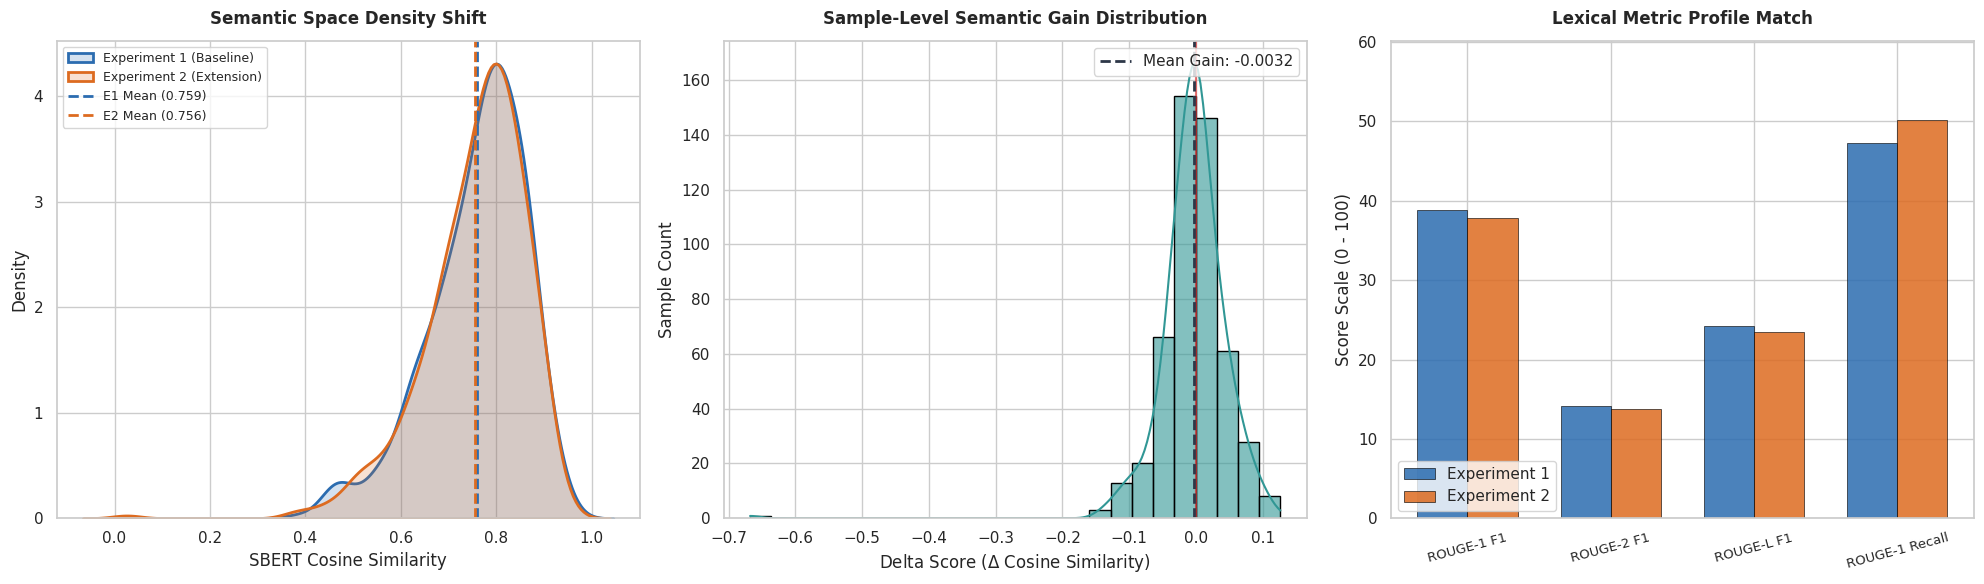

In [26]:
# @title Comprehensive Performance Visualization & Joint Analysis
# @markdown Aggregates metrics from lexical (ROUGE) and semantic (SBERT) evaluation dimensions to print a unified performance summary and plot distribution shifts.
# @markdown ---
# @markdown ### 🔴 VISUALIZATION DIAGNOSTIC GUIDE
# @markdown * **📈 PLOT 1: Semantic Space Density Shift (SBERT)** <br> Visualizes the probability distribution of cosine similarity scores across the entire dataset. This plot reveals the overall shape and central tendency of each model's semantic performance, showing the general range where most generated summaries fall relative to the human references.
# @markdown * **📊 PLOT 2: Sample-Level Semantic Gain Distribution (Delta)** <br> Displays the histogram of paired differences (Experiment 2 minus Experiment 1) for every individual text sample. This plot is designed to show the distribution of gains and losses, helping to determine if average improvements are driven by a broad, consistent uplift across many samples or simply skewed by a few massive outliers.
# @markdown * **📉 PLOT 3: Lexical Metric Profile Match (ROUGE)** <br> Provides a side-by-side bar chart comparison of exact n-gram overlap metrics. This plot highlights the mechanical trade-offs between the models, specifically showing how changes in the generation strategy impact strict vocabulary fidelity (Precision/F1) versus information capture (Recall).

import matplotlib.pyplot as plt
import seaborn as sns

def generate_comprehensive_report():

    try:
        with open(experiment_1_results_path, 'r') as f1:
            e1_metrics = json.load(f1)
        with open(experiment_2_results_path, 'r') as f2:
            e2_metrics = json.load(f2)
    except Exception as e:
        print(f"Error loading ROUGE files: {e}")
        return


    valid_size = len(experiment_1_data)
    sbert_a = np.zeros(valid_size)
    sbert_b = np.zeros(valid_size)

    for i in range(valid_size):
        try:
            s1 = experiment_1_data[i]
            s2 = experiment_2_data[i]
            reference = dataset[i][ref]
            sim_a, sim_b = compare_with_sbert(reference=reference, sentence_A=s1, sentence_B=s2)
            sbert_a[i] = sim_a
            sbert_b[i] = sim_b
        except:
            sbert_a[i] = np.nan
            sbert_b[i] = np.nan


    valid_mask = ~np.isnan(sbert_a) & ~np.isnan(sbert_b)
    sbert_a = sbert_a[valid_mask]
    sbert_b = sbert_b[valid_mask]
    sbert_deltas = sbert_b - sbert_a


    print("=" * 78)
    print(f"{'Evaluation Metric':<35} {'Experiment 1':>13} {'Experiment 2':>13} {'Delta':>13}")
    print("=" * 78)

    def print_combined_row(label, val1, val2):
        diff = val2 - val1
        diff_str = f"{diff:+12.4f}" if label != "Generation Length" else f"{diff:+12.2f}"
        fmt1 = f"{val1:>13.4f}" if label != "Generation Length" else f"{val1:>13.2f}"
        fmt2 = f"{val2:>13.4f}" if label != "Generation Length" else f"{val2:>13.2f}"
        print(f"{label:<35} {fmt1} {fmt2} {diff_str}")

    print_combined_row("ROUGE-1 F1", e1_metrics.get("rouge1f", 0), e2_metrics.get("rouge1f", 0))
    print_combined_row("ROUGE-2 F1", e1_metrics.get("rouge2f", 0), e2_metrics.get("rouge2f", 0))
    print_combined_row("ROUGE-L F1", e1_metrics.get("rougeLf", 0), e2_metrics.get("rougeLf", 0))
    print_combined_row("ROUGE-1 Recall", e1_metrics.get("rouge1r", 0), e2_metrics.get("rouge1r", 0))
    print_combined_row("Generation Length", e1_metrics.get("gen_len", 0), e2_metrics.get("gen_len", 0))
    print("-" * 78)
    print_combined_row("SBERT Cosine Sim (Mean)", np.mean(sbert_a), np.mean(sbert_b))
    print(f"{'SBERT Cosine Sim (StdDev)':<35} {np.std(sbert_a):>13.4f} {np.std(sbert_b):>13.4f} {'--':>13}")
    print("=" * 78)


    sns.set_theme(style="whitegrid", context="notebook")
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    palette = {"exp1": "#2B6CB0", "exp2": "#DD6B20", "delta": "#319795"}


    sns.kdeplot(sbert_a, fill=True, color=palette["exp1"], label="Experiment 1 (Baseline)", ax=axes[0], lw=2, alpha=0.2)
    sns.kdeplot(sbert_b, fill=True, color=palette["exp2"], label="Experiment 2 (Extension)", ax=axes[0], lw=2, alpha=0.2)
    axes[0].axvline(np.mean(sbert_a), color=palette["exp1"], linestyle="--", lw=2, label=f"E1 Mean ({np.mean(sbert_a):.3f})")
    axes[0].axvline(np.mean(sbert_b), color=palette["exp2"], linestyle="--", lw=2, label=f"E2 Mean ({np.mean(sbert_b):.3f})")
    axes[0].set_title("Semantic Space Density Shift", fontsize=12, fontweight='bold', pad=12)
    axes[0].set_xlabel("SBERT Cosine Similarity")
    axes[0].set_ylabel("Density")
    axes[0].legend(loc="upper left", frameon=True, fontsize=9)


    sns.histplot(sbert_deltas, kde=True, color=palette["delta"], ax=axes[1], bins=25, edgecolor='black', alpha=0.6)
    axes[1].axvline(0, color="#E53E3E", linestyle="-", lw=1.5, alpha=0.7)
    axes[1].axvline(np.mean(sbert_deltas), color="#2D3748", linestyle="--", lw=2,
                    label=f"Mean Gain: {np.mean(sbert_deltas):+.4f}")
    axes[1].set_title("Sample-Level Semantic Gain Distribution", fontsize=12, fontweight='bold', pad=12)
    axes[1].set_xlabel(r"Delta Score ($\Delta$ Cosine Similarity)")
    axes[1].set_ylabel("Sample Count")
    axes[1].legend(loc="upper right", frameon=True)


    metrics_labels = ['ROUGE-1 F1', 'ROUGE-2 F1', 'ROUGE-L F1', 'ROUGE-1 Recall']
    e1_vals = [e1_metrics.get("rouge1f", 0), e1_metrics.get("rouge2f", 0), e1_metrics.get("rougeLf", 0), e1_metrics.get("rouge1r", 0)]
    e2_vals = [e2_metrics.get("rouge1f", 0), e2_metrics.get("rouge2f", 0), e2_metrics.get("rougeLf", 0), e2_metrics.get("rouge1r", 0)]

    x = np.arange(len(metrics_labels))
    width = 0.35

    axes[2].bar(x - width/2, e1_vals, width, label='Experiment 1', color=palette["exp1"], alpha=0.85, edgecolor='black', lw=0.5)
    axes[2].bar(x + width/2, e2_vals, width, label='Experiment 2', color=palette["exp2"], alpha=0.85, edgecolor='black', lw=0.5)
    axes[2].set_title("Lexical Metric Profile Match", fontsize=12, fontweight='bold', pad=12)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(metrics_labels, rotation=15, fontsize=9.5)
    axes[2].set_ylabel("Score Scale (0 - 100)")
    axes[2].set_ylim(0, max(max(e1_vals), max(e2_vals)) + 10)
    axes[2].legend(loc="lower left", frameon=True)

    plt.tight_layout()
    plt.show()


generate_comprehensive_report()